In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

%matplotlib inline

In [2]:
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"

In [3]:
courses_df = pd.read_csv(course_genre_url)
rating_df = pd.read_csv(ratings_url)

## Exploratory Data Analysis
### Courses

In [4]:
courses_df.columns

Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
       'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
       'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
       'Blockchain'],
      dtype='object')

In [5]:
courses_df.shape[0]

307

In [6]:
courses_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [14]:
courses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   COURSE_ID        307 non-null    object
 1   TITLE            307 non-null    object
 2   Database         307 non-null    int64 
 3   Python           307 non-null    int64 
 4   CloudComputing   307 non-null    int64 
 5   DataAnalysis     307 non-null    int64 
 6   Containers       307 non-null    int64 
 7   MachineLearning  307 non-null    int64 
 8   ComputerVision   307 non-null    int64 
 9   DataScience      307 non-null    int64 
 10  BigData          307 non-null    int64 
 11  Chatbot          307 non-null    int64 
 12  R                307 non-null    int64 
 13  BackendDev       307 non-null    int64 
 14  FrontendDev      307 non-null    int64 
 15  Blockchain       307 non-null    int64 
dtypes: int64(14), object(2)
memory usage: 38.5+ KB


In [16]:
titles = " ".join(courses_df['TITLE'].astype(str))
titles[:200]

'robots are coming  build iot apps with watson  swift  and node red accelerating deep learning with gpu consuming restful services using the reactive jax rs client analyzing big data in r using apache '

In [17]:
stop_words = set(STOPWORDS)
stop_words.update(["getting started", "using", "enabling", "template", "university", "end", "introduction", "basic"])

In [21]:
wordcloud = WordCloud(stopwords=stop_words, background_color="white", width=800, height=400)
wordcloud.generate(titles)

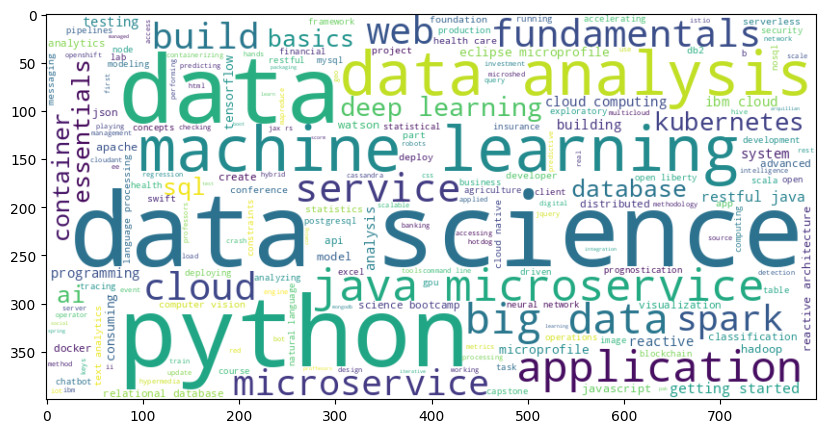

In [26]:
plt.figure(figsize=(14, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.show()

In [28]:
courses_df[courses_df.MachineLearning == 1].shape[0]

69

In [32]:
courses_df[(courses_df.MachineLearning == 1) & (courses_df.BigData == 1)].shape[0]

4

In [34]:
genres = courses_df.columns[2:]
genres

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='object')

In [37]:
genres_sum_sort = pd.DataFrame(courses_df[genres].sum(axis=0), columns=["Count"]).sort_values(by="Count",
                                                                                              ascending=False)
genres_sum_sort

,Count
BackendDev,78
MachineLearning,69
Database,60
DataAnalysis,56
DataScience,38
CloudComputing,37
BigData,36
Python,28
FrontendDev,19
Containers,17


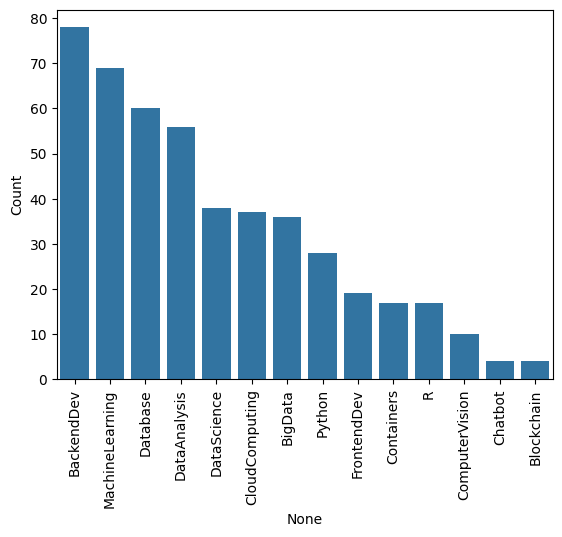

In [42]:
ax = sns.barplot(x=genres_sum_sort.index, y=genres_sum_sort["Count"])
ax.tick_params(axis='x', rotation=90)

### Enrollments

In [43]:
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


In [44]:
rating_df.rating.unique()

array([5, 3, 4])

In [45]:
rating_df.shape[0]

233306

In [52]:
user_counting = rating_df.groupby(rating_df.user).size().rename("rating_count")
user_counting

user
2          61
4          44
5          59
7           1
8           3
           ..
2102054     8
2102356     1
2102680    11
2102983     1
2103039     1
Name: rating_count, Length: 33901, dtype: int64

In [49]:
user_counting.describe()

count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
dtype: float64

<Axes: ylabel='Count'>

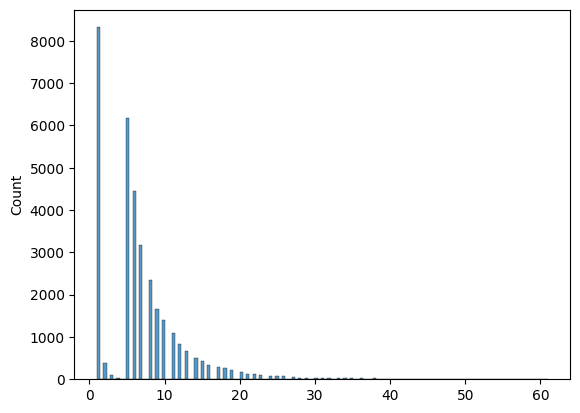

In [50]:
sns.histplot(data=user_counting)

In [57]:
items_count = rating_df.groupby([rating_df.item]).size().reset_index()
items_count.columns = ["course", "Ratings"]
items_count = items_count.sort_values(by="Ratings", ascending=False).reset_index(drop=True)
top_20_items_count = items_count[:20]
top_20_items_count

,course,Ratings
0,PY0101EN,14936
1,DS0101EN,14477
2,BD0101EN,13291
3,BD0111EN,10599
4,DA0101EN,8303
5,DS0103EN,7719
6,ML0101ENv3,7644
7,BD0211EN,7551
8,DS0105EN,7199
9,BC0101EN,6719


In [61]:
title_enrollments = \
    pd.merge(items_count[["course", "Ratings"]], courses_df[["COURSE_ID", "TITLE"]], how="left", left_on="course",
             right_on="COURSE_ID")[["TITLE", "Ratings"]]
title_enrollments.head()

,TITLE,Ratings
0,python for data science,14936
1,introduction to data science,14477
2,big data 101,13291
3,hadoop 101,10599
4,data analysis with python,8303


In [65]:
number_of_ratings = rating_df.shape[0]
top = top_20_items_count.Ratings.sum()
print(f"Percentage of total rating: {round(top * 100 / number_of_ratings, 2)}%")

Percentage of total rating: 63.3%
